In [1]:
from scipy.fft import fft

import numpy as np
from matplotlib import pyplot as plt
%config InlineBackend.figure_formats = ['svg']

import IPython.display as ipd


from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


In [2]:
from scipy.fft import fft

import numpy as np
from matplotlib import pyplot as plt
%config InlineBackend.figure_formats = ['svg']

import IPython.display as ipd


from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


While physical processes are time-contiunous and have continuous values, 
DSP systems usually work with signals that are both discrete in time and values.
Converting a signal from the physical domain - for example sound or voltage - to the digital domain - for example buffer in a computer's memory- 
involves two basic operations:

- **Sampling**  is the process of measuring the value of a (physical) signal at equidistant time instances. The sampling process has a direct impact on the temporal resolution of the digital signal.

- **Quantization** is the process of converting continuous values of a signal to a finite set of discrete values.

-----

The process of converting a physical signal $x(t)$ to a time-discrete and quantized array of values $x^*[n]$ is represented by the following flow chart:

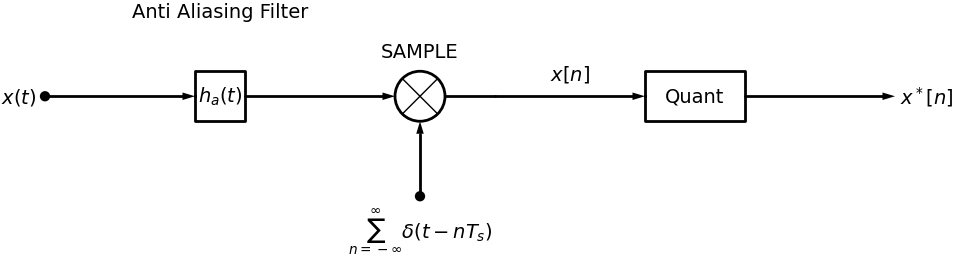

In [3]:
import schemdraw
from schemdraw import flow
from schemdraw import dsp

with schemdraw.Drawing() as d:
    schemdraw.config(fontsize=10, unit=1)
    flow.Dot().label('$x(t)$',loc='left')
    flow.Arrow().length(d.unit)  
    dsp.Square().label('$h_a(t)$').label('Anti Aliasing Filter',loc='top', ofst=1)
    flow.Arrow().length(d.unit)  
    
    mix = dsp.Mixer().label('SAMPLE')
   
    flow.Dot().at((7.5,-2)).label('$\sum_{n=-\infty}^{\infty} \delta(t-nT_s)$',loc='bottom')

    
    dsp.Arrow().up(1.5)
    
    #dsp.Line().at(mix.S).down(d.unit/3)
    
    dsp.Line().at(mix.E).right(d.unit/3)
    flow.Arrow().length(d.unit).label('$x[n]$') 
    
    flow.Process(w=2,h=1).label('Quant')
    flow.Arrow().length(d.unit).label('$x^*[n]$',loc='right') 

-----

The **anti-aliasing filter** $h_a(t)$ is a low-pass filter. It discards frequencies that are too high for the sampling rate $f_s$ of the system. This will be treated in more detail with the *Nyquist–Shannon Sampling Theorem*.
The actual sampling is modelled as a multiplication of $x(t)$ with a series of equidistant Dirac impulses with a distance of $T_s = \frac{1}{f_s}$. 
The sampled signal is then quantized.


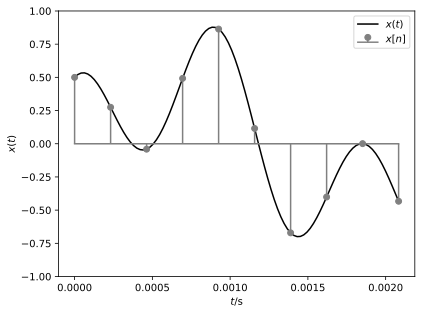

In [4]:
# 1000 Hz sampling rate
fs = 48000

# time vector with N samples length
N  = 100
f0 = 400
Nsteps = 8


t  = np.linspace(0,N,N)/fs
n  = np.linspace(0,N,int(N/10))/fs
x  = 0.5*np.sin(2*np.pi*f0*t)+0.5*np.cos(2*np.pi*2.7*f0*t)
x2  = 0.5*np.sin(2*np.pi*f0*n)+0.5*np.cos(2*np.pi*2.7*f0*n)

fig = plt.figure()
ax2 = fig.add_subplot(1, 1, 1)
ax2.set_ylim(-1, 1)    
line1, = ax2.plot(t,x,'k')

plt.stem(n,x2,'gray', basefmt="gray")


plt.xlabel('$t / \mathrm{s}$')
plt.ylabel('$x(t)$');

plt.legend(['$x(t)$','$x[n]$']);



-----

# Digital-Analog Conversion

Digital-Analog Conversion (DAC) is the process of turning a digital signal (or values stored in a buffer) into a phzsical signal, for example voltage. 
A DAC requires a *sample and hold* cirquit, that converts the digital sequence $x^*[n]$ in a buffer into a stepwise function $x^*[n]$. This stepwise function is then smoothed with an **interpolation filter** - again a low-pass filter - $h_i(t)$.

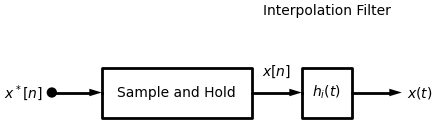

In [5]:
import schemdraw
from schemdraw import flow
from schemdraw import dsp

with schemdraw.Drawing() as d:
    schemdraw.config(fontsize=10, unit=1)
    flow.Dot().label('$x^*[n]$',loc='left')
    flow.Arrow().length(d.unit)  
    flow.Process(w=3,h=1).label('Sample and Hold')
    flow.Arrow().length(d.unit).label('$x[n]$')   
    dsp.Square().label('$h_i(t)$').label('Interpolation Filter',loc='top', ofst=1)
    flow.Arrow().length(d.unit).label('$x(t)$',loc='right') 


-----

The figure below shows how the stepwise function is smoothed with the interpolation filter:

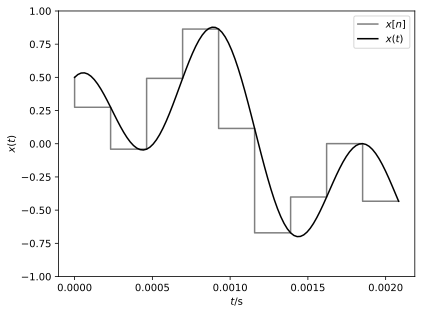

In [6]:
# 1000 Hz sampling rate
fs = 48000

# time vector with N samples length
N  = 100
f0 = 400
Nsteps = 8


t  = np.linspace(0,N,N)/fs
n  = np.linspace(0,N,int(N/10))/fs
x  = 0.5*np.sin(2*np.pi*f0*t)+0.5*np.cos(2*np.pi*2.7*f0*t)
x2  = 0.5*np.sin(2*np.pi*f0*n)+0.5*np.cos(2*np.pi*2.7*f0*n)

fig = plt.figure()
ax2 = fig.add_subplot(1, 1, 1)
ax2.set_ylim(-1, 1)    

plt.step(n,x2,'gray')
line1, = ax2.plot(t,x,'k')


plt.xlabel('$t / \mathrm{s}$')
plt.ylabel('$x(t)$');

plt.legend(['$x[n]$','$x(t)$']);

------

# Why This Matters

Many aspects of both sampling and quantization, or ADC and DAC, belong to the discipline of audio technology and electrical engineering, rather than digital signal processing. It involves a lot of circuits and electrical engineering.
The implementation and details of these systems are thus not in the scope of this DSP section. 
However, both proceees are essential for the qualities of digital signals and systems.
They define the limits and boundaries of DSP applications and are thus crucial for understanding and designing algorithms.
